### Assembly taxonomic loss analysis

#### Single sample

In [45]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

In [3]:
trim_df = pl.read_csv('/home/ctbrown/scratch3/2026-assembly-loss-tax/outputs/trim/ERR2683639.gather.with-lineages.csv')
assem_df = pl.read_csv('/home/ctbrown/scratch3/2026-assembly-loss-tax/outputs/inflate/ERR2683639.gather.with-lineages.csv')

In [4]:
trim_df

intersect_bp,f_orig_query,f_match,f_unique_to_query,f_unique_weighted,average_abund,median_abund,std_abund,filename,name,md5,f_match_orig,unique_intersect_bp,gather_result_rank,remaining_bp,query_filename,query_name,query_md5,query_bp,ksize,moltype,scaled,query_n_hashes,query_abundance,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,potential_false_negative,n_unique_weighted_found,sum_weighted_found,total_weighted_hashes,lineage
i64,f64,f64,f64,f64,f64,f64,f64,str,str,str,f64,i64,i64,i64,str,str,str,i64,i64,str,i64,i64,bool,f64,f64,f64,f64,bool,i64,i64,i64,str
3266000,0.02519,0.840021,0.02519,0.053397,4.896203,4.0,3.360181,"""/group/ctbrowngrp5/sourmash-db…","""GCF_024808235.1 Salinibacter r…","""41c576100ffe3315afa880da8c779e…",0.840021,3266000,0,126388000,"""outputs/trim/ERR2683639.trim.f…","""ERR2683639""","""c7600631""",129654000,31,"""DNA""",1000,129654,true,0.888028,0.994392,0.94121,0.994392,false,15991,15991,299472,"""d__Bacteria;p__Bacteroidota_A;…"
3237000,0.024966,0.919772,0.024936,0.110555,10.240643,10.0,6.214557,"""/group/ctbrowngrp5/sourmash-db…","""GCA_903989525.1 Haloquadratum …","""29c77bcaf8b38d9d31c8c989cdae59…",0.92091,3233000,1,123155000,"""outputs/trim/ERR2683639.trim.f…","""ERR2683639""","""c7600631""",129654000,31,"""DNA""",1000,129654,true,0.887773,0.997346,0.942559,0.997346,false,33108,49099,299472,"""d__Archaea;p__Halobacteriota;c…"
2349000,0.018117,0.859181,0.018117,0.029766,3.794806,3.0,2.721741,"""/group/ctbrowngrp5/sourmash-db…","""GCF_937146585.1 uncultured Hal…","""eda043e515541e01d4f654e3b2c45e…",0.859181,2349000,2,120806000,"""outputs/trim/ERR2683639.trim.f…","""ERR2683639""","""c7600631""",129654000,31,"""DNA""",1000,129654,true,0.878637,0.995116,0.936877,0.995116,false,8914,58013,299472,"""d__Archaea;p__Halobacteriota;c…"
1474000,0.011369,0.432792,0.011299,0.010532,2.152901,2.0,1.484332,"""/group/ctbrowngrp5/sourmash-db…","""GCA_937146515.1 uncultured Hal…","""cd2f5322fb1ec8cbf1ec86855a240c…",0.435451,1465000,3,119341000,"""outputs/trim/ERR2683639.trim.f…","""ERR2683639""","""c7600631""",129654000,31,"""DNA""",1000,129654,true,0.865528,0.973538,0.919533,0.973538,false,3154,61167,299472,"""d__Archaea;p__Halobacteriota;c…"
1417000,0.010929,0.520193,0.010829,0.009897,2.111111,2.0,1.659958,"""/group/ctbrowngrp5/sourmash-db…","""GCF_009184545.1 Halosegnis rub…","""516db63e3f2a14566963115326863d…",0.525009,1404000,4,117937000,"""outputs/trim/ERR2683639.trim.f…","""ERR2683639""","""c7600631""",129654000,31,"""DNA""",1000,129654,true,0.864427,0.979429,0.921928,0.979429,false,2964,64131,299472,"""d__Archaea;p__Halobacteriota;c…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1000,0.000008,0.00021,0.000008,0.000003,1.0,1.0,0.0,"""/group/ctbrowngrp5/sourmash-db…","""GCF_000701405.1 Deinococcus ma…","""f8f49292093cd86b4dad0646dc8894…",0.00021,1000,984,97316000,"""outputs/trim/ERR2683639.trim.f…","""ERR2683639""","""c7600631""",129654000,31,"""DNA""",1000,129654,true,0.684024,0.76098,0.722502,0.76098,true,1,111684,299472,"""d__Bacteria;p__Deinococcota;c_…"
1000,0.000008,0.000157,0.000008,0.000007,2.0,2.0,0.0,"""/group/ctbrowngrp5/sourmash-db…","""GCF_040642575.1 Micromonospora…","""ee09eddebe887401aabdaec5535f22…",0.000157,1000,985,97315000,"""outputs/trim/ERR2683639.trim.f…","""ERR2683639""","""c7600631""",129654000,31,"""DNA""",1000,129654,true,0.684024,0.75389,0.718957,0.75389,true,2,111686,299472,"""d__Bacteria;p__Actinomycetota;…"
5000,0.000039,0.000204,0.000008,0.000003,1.0,1.0,0.0,"""/group/ctbrowngrp5/sourmash-db…","""GCF_029168335.1 Psychromarinib…","""f14295203cbe61f8c52bc2c6283f65…",0.001018,1000,986,97314000,"""outputs/trim/ERR2683639.trim.f…","""ERR2683639""","""c7600631""",129654000,31,"""DNA""",1000,129654,true,0.720475,0.800698,0.760587,0.800698,true,1,111687,299472,"""d__Bacteria;p__Pseudomonadota;…"


In [5]:
assem_df

intersect_bp,f_orig_query,f_match,f_unique_to_query,f_unique_weighted,average_abund,median_abund,std_abund,filename,name,md5,f_match_orig,unique_intersect_bp,gather_result_rank,remaining_bp,query_filename,query_name,query_md5,query_bp,ksize,moltype,scaled,query_n_hashes,query_abundance,query_containment_ani,match_containment_ani,average_containment_ani,max_containment_ani,potential_false_negative,n_unique_weighted_found,sum_weighted_found,total_weighted_hashes,lineage
i64,f64,f64,f64,f64,f64,f64,f64,str,str,str,f64,i64,i64,i64,str,str,str,i64,i64,str,i64,i64,bool,f64,f64,f64,f64,bool,i64,i64,i64,str
3006000,0.058056,0.855192,0.058056,0.163059,10.757485,10.0,6.087688,"""/group/ctbrowngrp5/sourmash-db…","""GCA_903989525.1 Haloquadratum …","""29c77bcaf8b38d9d31c8c989cdae59…",0.855192,3006000,0,48772000,null,"""ERR2683639.assembly""","""24cee0c2""",51778000,31,"""DNA""",1000,51778,true,0.912271,0.994967,0.953619,0.994967,false,32337,32337,198315,"""d__Archaea;p__Halobacteriota;c…"
2834000,0.054734,0.728138,0.054676,0.076318,5.346167,5.0,3.348411,"""/group/ctbrowngrp5/sourmash-db…","""GCF_024808235.1 Salinibacter r…","""41c576100ffe3315afa880da8c779e…",0.728909,2831000,1,45941000,null,"""ERR2683639.assembly""","""24cee0c2""",51778000,31,"""DNA""",1000,51778,true,0.910539,0.989852,0.950195,0.989852,false,15135,47472,198315,"""d__Bacteria;p__Bacteroidota_A;…"
2099000,0.040538,0.76774,0.040538,0.043038,4.066222,4.0,2.741855,"""/group/ctbrowngrp5/sourmash-db…","""GCF_937146585.1 uncultured Hal…","""eda043e515541e01d4f654e3b2c45e…",0.76774,2099000,2,43842000,null,"""ERR2683639.assembly""","""24cee0c2""",51778000,31,"""DNA""",1000,51778,true,0.901763,0.99151,0.946637,0.99151,false,8535,56007,198315,"""d__Archaea;p__Halobacteriota;c…"
1047000,0.020221,0.353904,0.020047,0.020296,3.877649,3.0,3.944639,"""/group/ctbrowngrp5/sourmash-db…","""GCF_003605635.1 Halonotius pte…","""e5d0556dbc3a162ad99b4ecfe75ee9…",0.356972,1038000,3,42804000,null,"""ERR2683639.assembly""","""24cee0c2""",51778000,31,"""DNA""",1000,51778,true,0.881756,0.967317,0.924537,0.967317,false,4025,60032,198315,"""d__Archaea;p__Halobacteriota;c…"
1018000,0.019661,0.297784,0.019468,0.012747,2.507937,2.0,1.604166,"""/group/ctbrowngrp5/sourmash-db…","""GCA_937146515.1 uncultured Hal…","""cd2f5322fb1ec8cbf1ec86855a240c…",0.300739,1008000,4,41796000,null,"""ERR2683639.assembly""","""24cee0c2""",51778000,31,"""DNA""",1000,51778,true,0.880957,0.961983,0.92147,0.961983,false,2528,62560,198315,"""d__Archaea;p__Halobacteriota;c…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
67000,0.001294,0.000541,0.000019,0.00001,2.0,2.0,0.0,"""/group/ctbrowngrp5/sourmash-db…","""GCF_009805855.1 Spiribacter ro…","""f93e440362dfb3ffd5a4da1716a36e…",0.036275,1000,607,32621000,null,"""ERR2683639.assembly""","""24cee0c2""",51778000,31,"""DNA""",1000,51778,true,0.806931,0.898537,0.852734,0.898537,false,2,91482,198315,"""d__Bacteria;p__Pseudomonadota;…"
3000,0.000058,0.000259,0.000019,0.00001,2.0,2.0,0.0,"""/group/ctbrowngrp5/sourmash-db…","""GCF_000737065.1 Thioclava atla…","""63cbf15d4307f0bfead9a0c378eda0…",0.000777,1000,608,32620000,null,"""ERR2683639.assembly""","""24cee0c2""",51778000,31,"""DNA""",1000,51778,true,0.729998,0.79377,0.761884,0.79377,true,2,91484,198315,"""d__Bacteria;p__Pseudomonadota;…"
1000,0.000019,0.000158,0.000019,0.00001,2.0,2.0,0.0,"""/group/ctbrowngrp5/sourmash-db…","""GCF_003344865.1 Euzebya pacifi…","""318b6b2d603e69d787c33d96ad9618…",0.000158,1000,609,32619000,null,"""ERR2683639.assembly""","""24cee0c2""",51778000,31,"""DNA""",1000,51778,true,0.704581,0.753966,0.729274,0.753966,true,2,91486,198315,"""d__Bacteria;p__Actinomycetota;…"


## Step 1: Compares two datasets: read-level vs assembly-level taxonomic hits

In [7]:
trim_df = trim_df.with_columns(
    family=pl.col('lineage').str.split(';').list.get(4)
)
assem_df = assem_df.with_columns(
    family=pl.col('lineage').str.split(';').list.get(4)
)

In [8]:
trim_family = get_family(trim_df)
assem_family = get_family(assem_df)

#### Summarize abundance per family
- Instead of asking: "Did this exact genome appear?"
- ask: "How much sequence support does this family have? (in reads level)"

In [9]:
trim_agg = trim_df.group_by('family').agg(pl.col('n_unique_weighted_found').sum().alias('trim_found'))
trim_agg.sort(by='trim_found', descending=True)

family,trim_found
str,i64
"""f__Haloferacaceae""",71369
"""f__Salinibacteraceae""",28131
"""f__Haloarculaceae""",7593
"""f__Rhodobacteraceae""",1146
"""f__Nitrococcaceae""",1139
…,…
"""f__Eubacteriaceae""",1
"""f__UBA3015""",1
"""f__CAIVHJ01""",1


In [10]:
assem_agg = assem_df.group_by('family').agg(pl.col('n_unique_weighted_found').sum().alias('assem_found'))
assem_agg.sort(by='assem_found', descending=True)

family,assem_found
str,i64
"""f__Haloferacaceae""",62252
"""f__Salinibacteraceae""",22590
"""f__Haloarculaceae""",4513
"""f__Nanosalinaceae""",631
"""f__Rhodobacteraceae""",380
…,…
"""f__Butyricicoccaceae""",1
"""f__UBA183""",1
"""f__Archaeoglobaceae""",1


## Check: is there anything in assem that is NOT in trim?

In [11]:
in_assem = set(assem_agg['family'].to_list())
in_trim = set(trim_agg['family'].to_list())

# only a few - but we could pull back to family maybe?
print(in_assem - in_trim)

{'f__Aeromonadaceae', 'f__SW-7-71-33'}


## Create a combined data frame. 

In [13]:
combo_df = (
    trim_family
    .join(
        assem_family,
        on="family",
        how="full",
        suffix="_assem"
    )
    .fill_null(0)
    .rename({
        "found":"trim_found",
        "found_assem":"assem_found"
    })
)

combo_df = combo_df.with_columns(

    (
        pl.col("trim_found")
        -
        pl.col("assem_found")
    )
    .alias("diff")

)

#### How many families disappear?

In [14]:
lost = combo_df.filter(pl.col("assem_found")==0)
lost_fraction = (lost.height / combo_df.height)
lost_fraction

0.6023391812865497

- Assembly loses many detected families.

#### abundance-weighted retention

In [15]:
total_retention = (
    combo_df["assem_found"].sum()
    /
    combo_df["trim_found"].sum()
)

total_retention

0.8191406494820439

- Although 60% of families disappear, 82% of weighted taxonomic signal remains.

#### Plot abundance vs assembly retention

In [16]:
combo_df = combo_df.with_columns((pl.col("assem_found") /pl.col("trim_found"))
    .alias("retention"))

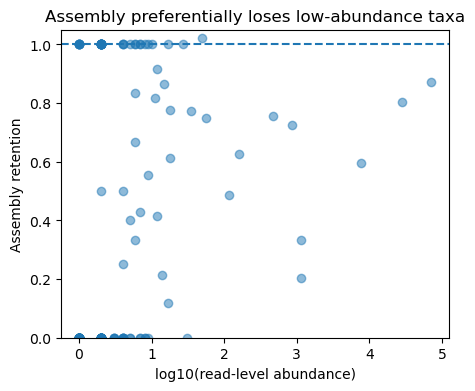

In [17]:
# 
plot_df = combo_df.filter(pl.col("trim_found") > 0)
plt.figure(figsize=(5,4))

plt.scatter(np.log10(plot_df["trim_found"]),
    plot_df["retention"],alpha=0.5)

plt.axhline(1,linestyle="--")
plt.xlabel("log10(read-level abundance)")
plt.ylabel("Assembly retention")
plt.title("Assembly preferentially loses low-abundance taxa")
plt.ylim(0,1.05)
plt.show()

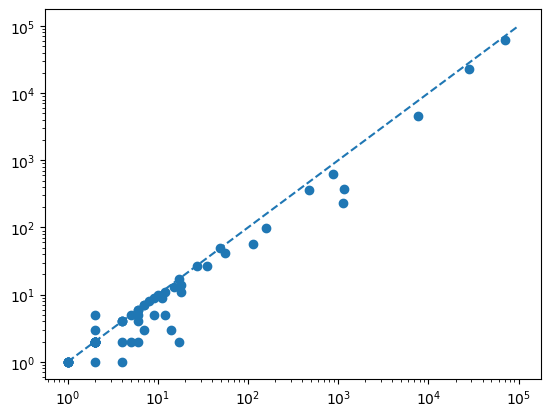

In [18]:
# Scatter plot
plt.scatter(
    combo_df["trim_found"],
    combo_df["assem_found"]
)

plt.xscale("log")
plt.yscale("log")
plt.plot(
    [1,100000],
    [1,100000],
    "--"
)

- Abundant taxa follow the expected line; rare taxa fall below it.

### 84 samples

In [37]:
from pathlib import Path
BASE = Path("/home/ctbrown/scratch3/2026-assembly-loss-tax/outputs")

trim_samples = {
    f.name.replace(".gather.with-lineages.csv", "")
    for f in (BASE / "trim").glob("*.gather.with-lineages.csv")
}

assem_samples = {
    f.name.replace(".gather.with-lineages.csv", "")
    for f in (BASE / "inflate").glob("*.gather.with-lineages.csv")
}
def analyze_sample(sample):

    trim = pl.read_csv(f"{PATH}/trim/{sample}.gather.with-lineages.csv")
    assem = pl.read_csv(f"{PATH}/inflate/{sample}.gather.with-lineages.csv")
    
    trim_family = get_family(trim)
    assem_family = get_family(assem)

    combo = (trim_family.join(
            assem_family,
            on="family",
            how="full",
            suffix="_assem"
        )
        .fill_null(0)
        .rename({
            "found":"trim_found",
            "found_assem":"assem_found"
        }))

    lost_fraction = ((combo["assem_found"]==0).sum()/combo.height)
    retention = (combo["assem_found"].sum()/combo["trim_found"].sum())

    return {
        "sample":sample,
        "families":combo.height,
        "lost_fraction":lost_fraction,
        "weighted_retention":retention
    }
samples = sorted(trim_samples & assem_samples)

print("Trim samples:", len(trim_samples))
print("Assembly samples:", len(assem_samples))
print("Matched samples:", len(samples))

print(samples[:10])

Trim samples: 84
Assembly samples: 84
Matched samples: 84
['DRR014782', 'DRR014785', 'DRR121397', 'DRR121401', 'ERR10695318', 'ERR1414265', 'ERR1414271', 'ERR1869526', 'ERR1869527', 'ERR1877479']


In [38]:
results = []
for sample in samples:results.append(analyze_sample(sample))
summary_df = pl.DataFrame(results)

In [39]:
summary_df

sample,families,lost_fraction,weighted_retention
str,i64,f64,f64
"""DRR014782""",371,0.74124,0.90488
"""DRR014785""",377,0.771883,0.894462
"""DRR121397""",952,0.607143,0.443769
"""DRR121401""",952,0.634454,0.386633
"""ERR10695318""",368,0.779891,0.996182
…,…,…,…
"""SRR7610133""",468,0.382479,0.971658
"""SRR9109404""",557,0.675045,0.972091
"""SRR9182859""",1502,0.61984,0.802456


/tmp/ipykernel_3792622/3886994443.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(lost_fraction,labels=["All samples"])


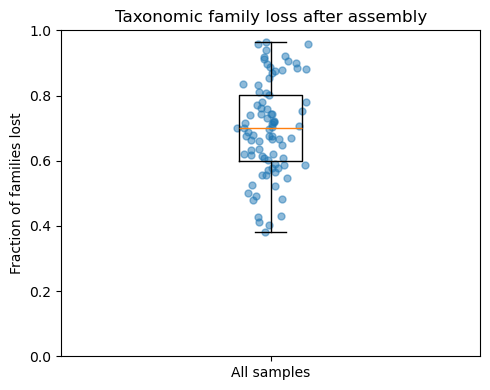

In [49]:
# fraction of families lost across all 84 samples
lost_fraction = summary_df["lost_fraction"].to_numpy()

plt.figure(figsize=(5, 4))
plt.boxplot(lost_fraction,labels=["All samples"])

# show individual samples
x = np.random.normal(1, 0.04, size=len(lost_fraction))

plt.scatter(x,lost_fraction,alpha=0.5,s=25)
plt.ylabel("Fraction of families lost")
plt.title("Taxonomic family loss after assembly")

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3792622/2494705108.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(retention,labels=["All samples"])


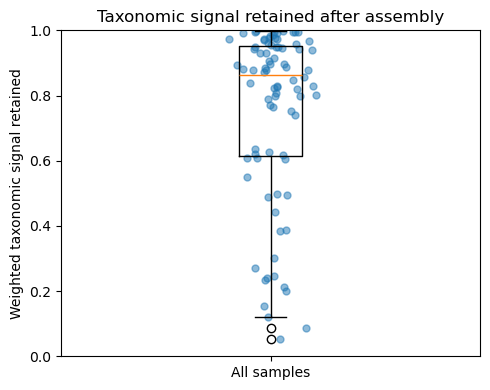

In [52]:
# weighted taxonomic signal retention across the 84 samples
retention = summary_df["weighted_retention"].to_numpy()

plt.figure(figsize=(5, 4))
plt.boxplot(retention,labels=["All samples"])

x = np.random.normal(1, 0.04, size=len(retention))
plt.scatter(x,retention,alpha=0.5,s=25)

plt.ylabel("Weighted taxonomic signal retained")
plt.title("Taxonomic signal retained after assembly")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [54]:
summary_stats = pl.DataFrame({
    "Metric": [
        "Fraction of families lost",
        "Weighted taxonomic signal retained"],
    "Mean": [
        summary_df["lost_fraction"].mean(),
        summary_df["weighted_retention"].mean()],
    "Median": [
        summary_df["lost_fraction"].median(),
        summary_df["weighted_retention"].median()],
    "Q1": [
        summary_df["lost_fraction"].quantile(0.25),
        summary_df["weighted_retention"].quantile(0.25)],
    "Q3": [
        summary_df["lost_fraction"].quantile(0.75),
        summary_df["weighted_retention"].quantile(0.75)],
    "Min": [
        summary_df["lost_fraction"].min(),
        summary_df["weighted_retention"].min()],
    "Max": [
        summary_df["lost_fraction"].max(),
        summary_df["weighted_retention"].max()]
})

summary_stats

Metric,Mean,Median,Q1,Q3,Min,Max
str,f64,f64,f64,f64,f64,f64
"""Fraction of families lost""",0.697576,0.700171,0.602339,0.800518,0.382479,0.965517
"""Weighted taxonomic signal reta…",0.751678,0.863537,0.617296,0.949365,0.053024,0.997741


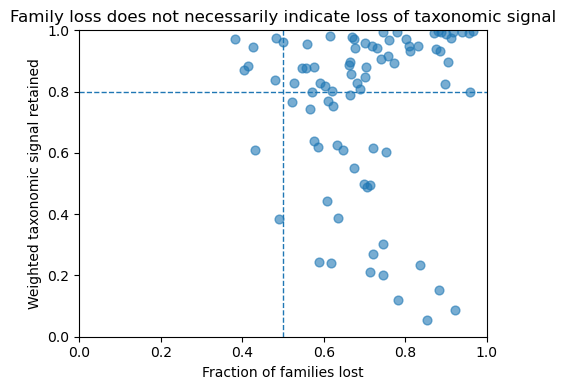

In [56]:
# 
import matplotlib.pyplot as plt
import numpy as np

x = summary_df["lost_fraction"].to_numpy()
y = summary_df["weighted_retention"].to_numpy()

plt.figure(figsize=(5, 4))

plt.scatter(
    x,
    y,
    s=40,
    alpha=0.6
)

# Reference lines
plt.axvline(
    0.5,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    0.8,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Fraction of families lost")
plt.ylabel("Weighted taxonomic signal retained")

plt.title(
    "Family loss does not necessarily indicate loss of taxonomic signal"
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [57]:
# Abundance-dependent retention across all samples
all_family_results = []

for sample in samples:
    trim = pl.read_csv(
        f"{PATH}/trim/{sample}.gather.with-lineages.csv"
    )

    assem = pl.read_csv(
        f"{PATH}/inflate/{sample}.gather.with-lineages.csv"
    )

    trim_family = get_family(trim)
    assem_family = get_family(assem)

    combo = (
        trim_family
        .join(
            assem_family,
            on="family",
            how="full",
            suffix="_assem"
        )
        .fill_null(0)
        .rename({
            "found": "trim_found",
            "found_assem": "assem_found"
        })
        .with_columns(
            pl.lit(sample).alias("sample")
        )
    )

    all_family_results.append(combo)

all_family_df = pl.concat(all_family_results)

In [58]:
all_family_df = all_family_df.with_columns(
    (
        pl.col("assem_found") /
        pl.col("trim_found")
    ).alias("retention")
)

In [59]:
plot_df = all_family_df.filter(
    pl.col("trim_found") > 0
)

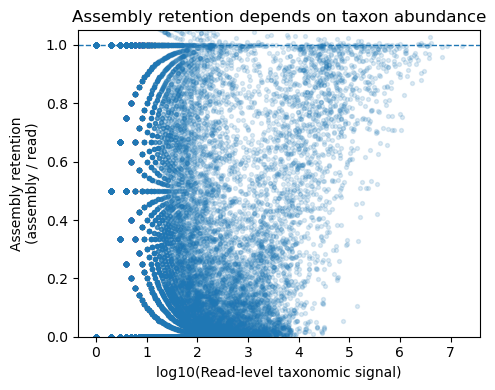

In [65]:
x = np.log10(
    plot_df["trim_found"].to_numpy()
)

y = plot_df["retention"].to_numpy()

plt.figure(figsize=(5, 4))

plt.scatter(
    x,
    y,
    s=8,
    alpha=0.15
)

plt.axhline(
    1,
    linestyle="--",
    linewidth=1
)

plt.xlabel("log10(Read-level taxonomic signal)")
plt.ylabel("Assembly retention\n(assembly / read)")

plt.ylim(0, 1.05)

plt.title(
    "Assembly retention depends on taxon abundance"
)

plt.tight_layout()
plt.show()

In [61]:
# Create abundance bins
binned = (
    plot_df
    .with_columns(
        pl.col("trim_found")
        .log10()
        .alias("log_abundance")
    )
    .with_columns(
        pl.when(pl.col("log_abundance") < 1)
        .then(pl.lit("1–10"))
        .when(pl.col("log_abundance") < 2)
        .then(pl.lit("10–100"))
        .when(pl.col("log_abundance") < 3)
        .then(pl.lit("100–1,000"))
        .when(pl.col("log_abundance") < 4)
        .then(pl.lit("1,000–10,000"))
        .otherwise(pl.lit(">10,000"))
        .alias("abundance_bin")
    )
)

bin_summary = (
    binned
    .group_by("abundance_bin")
    .agg(
        pl.col("retention").median().alias("median_retention"),
        pl.col("retention").quantile(0.25).alias("q25"),
        pl.col("retention").quantile(0.75).alias("q75"),
        pl.len().alias("n")
    )
)

bin_summary

abundance_bin,median_retention,q25,q75,n
str,f64,f64,f64,u32
"""10–100""",0.1,0.0,0.5,13207
"""100–1,000""",0.11098,0.017182,0.375,4316
"""1,000–10,000""",0.228471,0.056218,0.50723,1863
"""1–10""",0.0,0.0,0.0,43877
""">10,000""",0.816292,0.620005,0.944174,1050


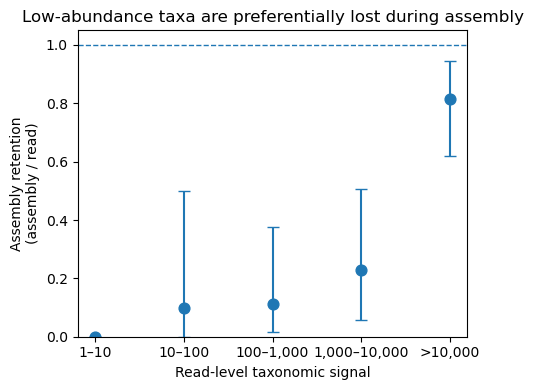

In [64]:
bin_order = [
    "1–10",
    "10–100",
    "100–1,000",
    "1,000–10,000",
    ">10,000"
]

plot_summary = (
    bin_summary
    .with_columns(
        pl.col("abundance_bin")
        .cast(
            pl.Enum(bin_order)
        )
    )
    .sort("abundance_bin")
)

x = np.arange(len(plot_summary))

median = plot_summary["median_retention"].to_numpy()
q25 = plot_summary["q25"].to_numpy()
q75 = plot_summary["q75"].to_numpy()

plt.figure(figsize=(5, 4))

plt.scatter(
    x,
    median,
    s=60
)

plt.errorbar(
    x,
    median,
    yerr=[
        median - q25,
        q75 - median
    ],
    fmt="none",
    capsize=4
)

plt.axhline(
    1,
    linestyle="--",
    linewidth=1
)

plt.xticks(
    x,
    bin_order
)

plt.xlabel("Read-level taxonomic signal")
plt.ylabel("Assembly retention\n(assembly / read)")

plt.ylim(0, 1.05)

plt.title(
    "Low-abundance taxa are preferentially lost during assembly"
)

plt.tight_layout()
plt.show()

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

# Keep taxa detected at the read level
plot_df = (
    all_family_df
    .filter(pl.col("trim_found") > 0)
    .with_columns(
        (
            pl.col("assem_found") /
            pl.col("trim_found")
        ).alias("retention"),

        pl.col("trim_found")
        .log10()
        .alias("log_abundance")
    )
)

# Abundance bins: 1-10, 10-100, 100-1,000, ...
bins = [0, 1, 2, 3, 4, 5, 6, np.inf]
labels = [
    "1–10",
    "10–100",
    "100–1,000",
    "1,000–10,000",
    "10,000–100,000",
    ">100,000"
]

# Assign bins
plot_df = plot_df.with_columns(
    pl.when(pl.col("log_abundance") < 1)
    .then(pl.lit("1–10"))
    .when(pl.col("log_abundance") < 2)
    .then(pl.lit("10–100"))
    .when(pl.col("log_abundance") < 3)
    .then(pl.lit("100–1,000"))
    .when(pl.col("log_abundance") < 4)
    .then(pl.lit("1,000–10,000"))
    .when(pl.col("log_abundance") < 5)
    .then(pl.lit("10,000–100,000"))
    .otherwise(pl.lit(">100,000"))
    .alias("abundance_bin")
)

# Summarize each abundance bin
bin_summary = (
    plot_df
    .group_by("abundance_bin")
    .agg([
        pl.col("retention").median().alias("median_retention"),
        pl.col("retention").quantile(0.25).alias("q25"),
        pl.col("retention").quantile(0.75).alias("q75"),
        (pl.col("retention") == 0).mean().alias("fraction_lost"),
        pl.len().alias("n")
    ])
)

# Put bins in the desired order
bin_summary = (
    bin_summary
    .with_columns(
        pl.col("abundance_bin").cast(
            pl.Enum(labels)
        )
    )
    .sort("abundance_bin")
)

bin_summary

abundance_bin,median_retention,q25,q75,fraction_lost,n
enum,f64,f64,f64,f64,u32
"""1–10""",0.0,0.0,0.0,0.838275,43877
"""10–100""",0.1,0.0,0.5,0.397289,13207
"""100–1,000""",0.11098,0.017182,0.375,0.147822,4316
"""1,000–10,000""",0.228471,0.056218,0.50723,0.012346,1863
"""10,000–100,000""",0.767771,0.538506,0.913694,0.0,778
""">100,000""",0.923658,0.815962,0.980621,0.0,272


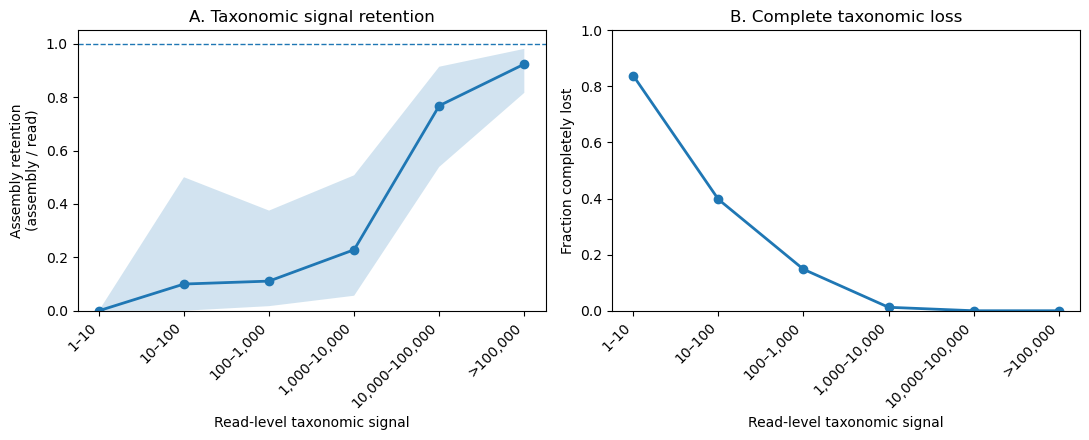

In [67]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 4.5)
)

x = np.arange(len(bin_summary))

median = bin_summary["median_retention"].to_numpy()
q25 = bin_summary["q25"].to_numpy()
q75 = bin_summary["q75"].to_numpy()

lost = bin_summary["fraction_lost"].to_numpy()
n = bin_summary["n"].to_numpy()

# -------------------------
# Panel A: retention
# -------------------------

axes[0].plot(
    x,
    median,
    marker="o",
    linewidth=2
)

axes[0].fill_between(
    x,
    q25,
    q75,
    alpha=0.2
)

axes[0].axhline(
    1,
    linestyle="--",
    linewidth=1
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(
    labels,
    rotation=45,
    ha="right"
)

axes[0].set_xlabel(
    "Read-level taxonomic signal"
)

axes[0].set_ylabel(
    "Assembly retention\n(assembly / read)"
)

axes[0].set_ylim(0, 1.05)

axes[0].set_title(
    "A. Taxonomic signal retention"
)

# -------------------------
# Panel B: complete loss
# -------------------------

axes[1].plot(
    x,
    lost,
    marker="o",
    linewidth=2
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(
    labels,
    rotation=45,
    ha="right"
)

axes[1].set_xlabel(
    "Read-level taxonomic signal"
)

axes[1].set_ylabel(
    "Fraction completely lost"
)

axes[1].set_ylim(0, 1)

axes[1].set_title(
    "B. Complete taxonomic loss"
)

plt.tight_layout()
plt.show()

In [68]:
plot_df.filter(
    pl.col("retention") > 1
).select([
    "sample",
    "family",
    "trim_found",
    "assem_found",
    "retention"
])

sample,family,trim_found,assem_found,retention
str,str,i64,i64,f64
"""DRR014782""","""f__Helicobacteraceae""",1409,1914,1.35841
"""DRR014782""","""f__Desulfovibrionaceae""",35446,35500,1.001523
"""DRR014782""","""f__Muribaculaceae""",2302293,2312425,1.004401
"""DRR014782""","""f__Bacteroidaceae""",1002774,1004794,1.002014
"""DRR014782""","""f__UBA1234""",4,6,1.5
…,…,…,…,…
"""SRR9182862""","""f__Desulfitobacteriaceae""",19,25,1.315789
"""SRR9182862""","""f__CSP1-6""",6,9,1.5
"""SRR9182862""","""f__BM103""",7,25,3.571429


In [13]:
combo_df = (trim_agg.join(assem_agg, on='family', how='left')
    .fill_null(0)
    .with_columns(diff=pl.col('trim_found') - pl.col('assem_found'))
    .sort(by='trim_found', descending=True)
    .with_row_index(name='index')
)
combo_df

index,family,trim_found,assem_found,diff
u32,str,i64,i64,i64
0,"""f__Haloferacaceae""",71369,62252,9117
1,"""f__Salinibacteraceae""",28131,22590,5541
2,"""f__Haloarculaceae""",7593,4513,3080
3,"""f__Rhodobacteraceae""",1146,380,766
4,"""f__Nitrococcaceae""",1139,232,907
…,…,…,…,…
164,"""f__SLST01""",1,0,1
165,"""f__CAIVHJ01""",1,0,1
166,"""f__Chitinophagaceae""",1,0,1


** calculate Retention= Read abundance / Assembly abundance **
- Instead of asking: Which families disappear after assembly?
- Ask: How much taxonomic signal survives after assembly?

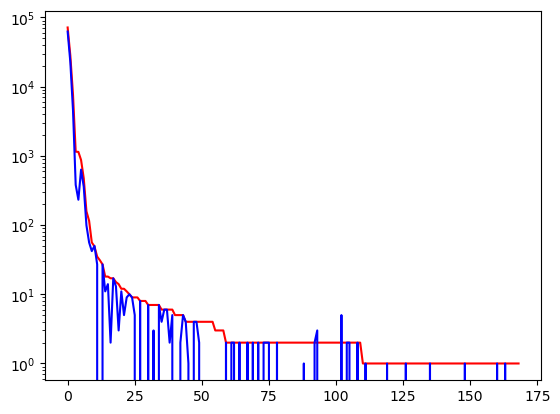

In [14]:
plt.plot(combo_df['index'], combo_df['trim_found'], 'r-')
plt.plot(combo_df['index'], combo_df['assem_found'], 'b-')
plt.yscale('log')

#### main biological message: abundant taxa are retained; rare taxa disappear.
- x-axis: Taxonomic rank (ordered by trim abundance)
- y-axis: assembly retention
- 

In [16]:
combo_df

index,family,trim_found,assem_found,diff
u32,str,i64,i64,i64
0,"""f__Haloferacaceae""",71369,62252,9117
1,"""f__Salinibacteraceae""",28131,22590,5541
2,"""f__Haloarculaceae""",7593,4513,3080
3,"""f__Rhodobacteraceae""",1146,380,766
4,"""f__Nitrococcaceae""",1139,232,907
…,…,…,…,…
164,"""f__SLST01""",1,0,1
165,"""f__CAIVHJ01""",1,0,1
166,"""f__Chitinophagaceae""",1,0,1


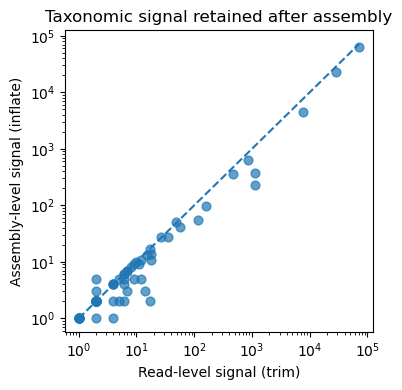

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

plot_df = combo_df.filter(
    (pl.col("trim_found") > 0) &
    (pl.col("assem_found") > 0)
)

x = plot_df["trim_found"].to_numpy()
y = plot_df["assem_found"].to_numpy()

plt.figure(figsize=(4,4))

plt.scatter(
    x,
    y,
    s=40,
    alpha=0.7
)

# diagonal reference line
lims = [
    min(x.min(), y.min()),
    max(x.max(), y.max())
]

plt.plot(
    lims,
    lims,
    "--"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Read-level signal (trim)")
plt.ylabel("Assembly-level signal (inflate)")

plt.title("Taxonomic signal retained after assembly")

plt.tight_layout()
plt.show()

In [19]:
ret_df = combo_df.with_columns(
    (
        pl.col("assem_found") /
        pl.col("trim_found")
    ).alias("retention")
)

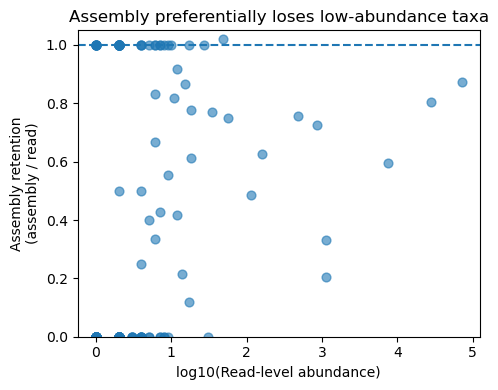

In [21]:
x = ret_df["trim_found"].to_numpy()
y = ret_df["retention"].to_numpy()

plt.figure(figsize=(5,4))

plt.scatter(
    np.log10(x),
    y,
    s=40,
    alpha=0.6
)

plt.axhline(
    1,
    linestyle="--"
)

plt.xlabel(
    "log10(Read-level abundance)"
)

plt.ylabel(
    "Assembly retention\n(assembly / read)"
)

plt.ylim(0,1.05)

plt.title(
    "Assembly preferentially loses low-abundance taxa"
)

plt.tight_layout()
plt.show()

In [22]:
total_retention = (
    combo_df["assem_found"].sum() /
    combo_df["trim_found"].sum()
)

total_retention

0.8190779754496862